In [1]:
import pandas as pd
from pathlib import Path

folder_path = Path("lushfoil_price_comps/")  # update this
all_csvs = []

for file in folder_path.glob("*.csv"):
    df = pd.read_csv(file)
    df["source_file"] = file.stem  # or file.name for full name with extension
    all_csvs.append(df)

combined_df = pd.concat(all_csvs, ignore_index=True)

In [2]:
combined_df["DateTime"] = pd.to_datetime(combined_df["DateTime"])

combined_df["DaysAfterLaunch"] = combined_df.groupby("source_file")["DateTime"] \
    .transform(lambda x: (x - x.min()).dt.days)

In [3]:
combined_df["LaunchDate"] = combined_df.groupby("source_file")["DateTime"].transform("min")

In [4]:
combined_df['year'] = combined_df['LaunchDate'].dt.year

In [5]:
bin_list  =  [0,180,365, 730, 1825]

In [6]:
combined_df

,DateTime,Final price,Historical Low,source_file,DaysAfterLaunch,LaunchDate,year
0,2019-02-13 15:20:09,21.24,21.24,eastshade,0,2019-02-13 15:20:09,2019
1,2019-02-20 18:20:36,24.99,21.24,eastshade,7,2019-02-13 15:20:09,2019
2,2019-04-22 17:13:52,21.24,21.24,eastshade,68,2019-02-13 15:20:09,2019
3,2019-04-29 17:34:47,24.99,21.24,eastshade,75,2019-02-13 15:20:09,2019
4,2019-06-03 23:10:24,19.99,19.99,eastshade,110,2019-02-13 15:20:09,2019
...,...,...,...,...,...,...,...
782,2025-02-17 18:21:28,14.99,1.49,umurangi,1735,2020-05-19 17:10:16,2020
783,2025-03-13 17:18:54,7.49,1.49,umurangi,1759,2020-05-19 17:10:16,2020
784,2025-03-20 18:03:27,14.99,1.49,umurangi,1766,2020-05-19 17:10:16,2020
785,2025-03-26 16:09:55,14.99,1.49,umurangi,1771,2020-05-19 17:10:16,2020


In [7]:
combined_df['bin'] = pd.cut(combined_df['DaysAfterLaunch'], bins=bin_list)

In [8]:
max_df = combined_df.groupby("source_file")['Final price'].max()
mean_df = combined_df.groupby("source_file")['Final price'].mean()

In [9]:
combined_df['Final price'].mean()

14.439344473007713

In [10]:
combined_df.groupby("bin")['Final price'].mean()

/var/folders/vh/qvl8gx_d2m370qv72srt5r1m0000gp/T/ipykernel_83832/460922471.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_df.groupby("bin")['Final price'].mean()


bin
(0, 180]       16.887619
(180, 365]     14.176667
(365, 730]     14.568425
(730, 1825]    14.095014
Name: Final price, dtype: float64

In [11]:
combined_df.groupby(["year"])['Final price'].mean()

year
2013     6.974655
2016    13.995814
2017    18.222772
2019    18.981071
2020    11.571724
2021    15.017419
2024     5.390000
Name: Final price, dtype: float64

In [12]:
max_df - mean_df

source_file
Yonder            6.767228
abzu              5.994186
eastshade         6.008929
journey           4.008222
lake              4.347541
proteus           3.015345
shutter_stroll    0.600000
toem              5.577778
umurangi          2.786190
Name: Final price, dtype: float64

In [13]:
mean_df

source_file
Yonder            18.222772
abzu              13.995814
eastshade         18.981071
journey           10.981778
lake              15.642459
proteus            6.974655
shutter_stroll     5.390000
toem              14.412222
umurangi          12.203810
Name: Final price, dtype: float64

In [14]:
max_df

source_file
Yonder            24.99
abzu              19.99
eastshade         24.99
journey           14.99
lake              19.99
proteus            9.99
shutter_stroll     5.99
toem              19.99
umurangi          14.99
Name: Final price, dtype: float64

In [15]:
### New Zoo Data

In [16]:
NZ = pd.read_excel("Game Engagement - table 2025-02-01.xlsx")

In [17]:
pd.set_option("display.max_columns", None)
NZ

,Start date,Period,Geo type,Geo selection,Game,Publisher,Genre,Platforms tracked,Markets,Subgenre,Steam tags,Monetization,Current MSRP,Launch MSRP,Franchise,Developer,Theme,Art style,Supported Platforms,VR Support,Game mechanics,Game modes,Number of players,Competitiveness,Avatar number,Perspective,Dimensionality,Game engines,IP Rights Owner,IP Origin,IP Medium,Release date,ESRB Rating,ESRB Content descriptor,Player share,MAU,MAU - new,MAU - returning,Lifetime players,Avg. daily playtime (mins),Avg. daily sessions,Avg. playtime / session (mins),Avg. monthly playtime (hours),Avg. monthly sessions,Avg. days played,Stickiness,Total hours,Churn %,Acquisition %,0 - 1 (hours),1 - 5 (hours),5 - 10 (hours),10 - 25 (hours),25 - 50 (hours),>50 (hours),Day 1,Day 2,Day 4,Day 7,Day 14,Day 28,Steam reviews,Steam reviews positive %,Steam wishlists,Steam followers
0,2025-02-01,month,Region,['All regions'],Open Roads,Annapurna Interactive,Adventure,['Xbox Series X|S'],2.0,['Narrative Adventure'],"['3D', '2D', 'Linear', 'Detective', 'Story Ric...",['Pay-to-Play'],19.99,19.99,['No Franchise'],['Open Roads Team'],"['Modern Day', 'Mystery / Detective']",['Stylized Realism'],"['Nintendo Switch', 'PC (Steam)', 'PlayStation...",['No VR'],['Dialogue Trees'],['Story Mode / Campaign'],['Single Player'],['PvE'],['Control over a Single Entity'],"['First Person View', 'Side View']",['3D'],['Unity'],[],[],[],2024-03-28,['Teen'],"['Alcohol and Tobacco Reference', 'Blood', 'La...",0.0002,8302.0,5839.0,2463.0,326800.0,135.2922,1.0001,124.4403,2.7051,1.1995,1.1993,0.0428,2.065295e+04,NaN,NaN,0.5000,0.4545,0.0455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240.0,0.7667,NaN,6682.0
1,2025-02-01,month,Region,['All regions'],REVEIL,Daedalic Entertainment,Adventure,[],NaN,['Narrative Adventure'],"['Drama', 'Dark', 'First-Person', 'Exploration...",['Pay-to-Play'],19.99,19.99,['No Franchise'],['Pixelsplit'],"['Mystery / Detective', 'Psychological Horror']",['Realistic'],"['Mac', 'PC (Steam)', 'PlayStation 5', 'Windows']",['No VR'],"['Jump Scares', 'Puzzle Solving']",['Story Mode / Campaign'],['Single Player'],['PvE'],['Control over a Single Entity'],['First Person View'],['3D'],['Unity'],[],[],[],2024-03-06,['Mature 17+'],"['Blood and Gore', 'Mild Violence', 'Strong La...",NaN,NaN,NaN,NaN,8016.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,648.0,0.8920,NaN,5351.0
2,2025-02-01,month,Region,['All regions'],Supermarket Simulator (2024),Nokta Games,Simulation,['PC (Steam)'],28.0,['Job Simulator'],"['Realistic', 'Immersive Sim', 'Economy', 'Man...",['Pay-to-Play'],12.99,12.99,['No Franchise'],['Nokta Games'],['Modern Day'],['Realistic'],"['PC (Steam)', 'Windows']",['No VR'],"['Building', 'Character Progression (permanent...","['Sandbox / Free Play', 'Story Mode / Campaign']",['Single Player'],['PvE'],['Control over a Single Entity'],['First Person View'],['3D'],['Unity'],[],[],[],2024-02-20,['Everyone'],[],0.0039,263624.0,63873.0,199751.0,2684131.0,108.9995,1.2935,102.9540,6.2063,4.1775,3.2297,0.1042,1.889718e+06,NaN,NaN,0.3161,0.3212,0.1658,0.1658,0.0207,0.0104,NaN,NaN,NaN,NaN,NaN,NaN,62405.0,0.9390,NaN,103871.0
3,2025-02-01,month,Region,['All regions'],I Wani Hug that Gator!,NaN,Adventure,[],NaN,[],"['Cute', 'Choices Matter', 'Story Rich', 'Dino...",[],14.99,14.99,[],[],[],[],[],[],[],[],[],[],[],[],[],"[""Ren'Py""]",[],[],[],2024-02-14,[],[],NaN,NaN,NaN,NaN,16209.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4351.0,0.9890,NaN,7200.0
4,2025-02-01,month,Region,['All regions'],Secrets of Grindea,NaN,Role Playing,[],NaN,[],"['RPG', 'Co-op Campaign', 'JRPG', 'Action RPG'...",['Pay-to-Play'],14.99,14.99,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],2024-02-29,[],[],NaN,NaN,NaN,NaN,251548.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8087.0,0.8938,NaN,76013.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [18]:
cols = ['Start date',  ' Game',
       'Publisher', 'Monetization', 'Current MSRP', 'Launch MSRP',
       'Release date', 'ESRB Rating', 'ESRB Content descriptor',
       'Player share', 
       'Lifetime players','Steam reviews positive %','Steam wishlists', 'Avg. days played', 'Stickiness']

In [19]:
NZ[cols]['Launch MSRP'].mean()

16.674434628975263

In [20]:
NZ[cols]['Current MSRP'].mean()

16.40765017667844

In [21]:
data = NZ[cols]

In [22]:
data = data.dropna(subset='Lifetime players')

In [23]:
data['Release date'] = pd.to_datetime(data['Release date'])
data['year'] = data['Release date'].dt.year



In [24]:
data.groupby(["year"])['Launch MSRP'].mean()

year
2020    15.672817
2021    16.634952
2022    16.765396
2023    18.077500
2024    16.717273
Name: Launch MSRP, dtype: float64

In [25]:
data = data.sort_values(by='Release date')

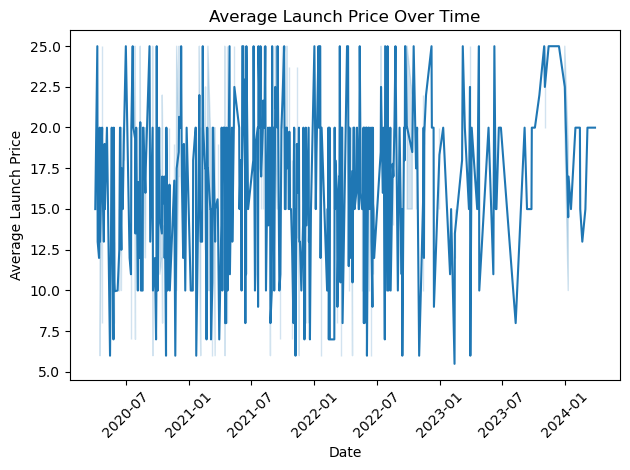

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=data, x='Release date', y='Launch MSRP')
plt.title('Average Launch Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Launch Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

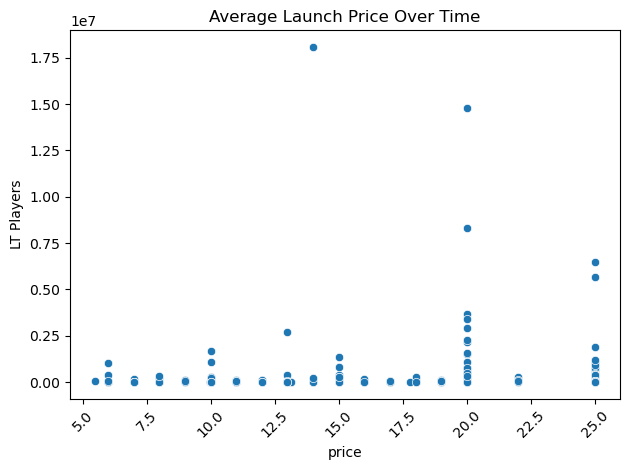

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=data, x='Launch MSRP', y='Lifetime players')
plt.title('Average Launch Price Over Time')
plt.xlabel('price')
plt.ylabel('LT Players')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=data, x='Launch MSRP', y='Lifetime players')
plt.title('Average Launch Price Over Time')
plt.xlabel('price')
plt.ylabel('LT Players')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
bin_list_nz = [
    0,5,10,15,20, 30
]

In [29]:
data['bin'] = pd.cut(data['Launch MSRP'], bins=bin_list_nz)

<Axes: xlabel='Steam reviews positive %', ylabel='bin'>

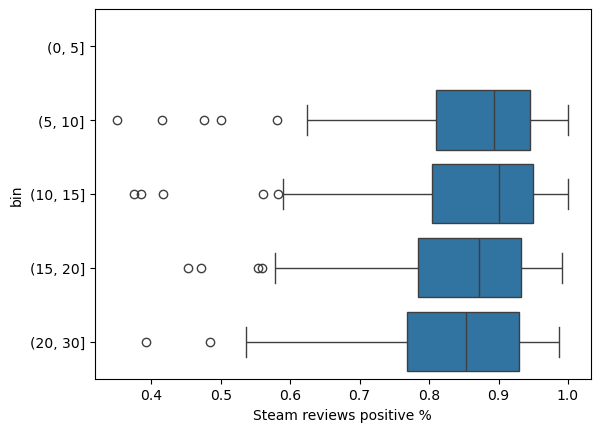

In [30]:
sns.boxplot(data=data, x='Steam reviews positive %', y='bin')


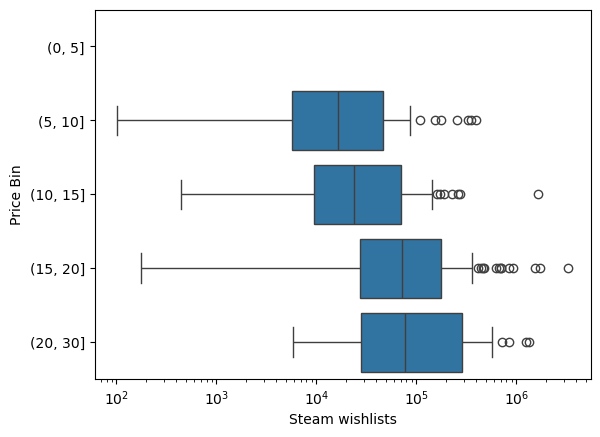

In [70]:
sns.boxplot(data=data, x='Steam wishlists', y='bin')
plt.ylabel("Price Bin")
plt.xscale("log")

Text(0, 0.5, 'Price Bin')

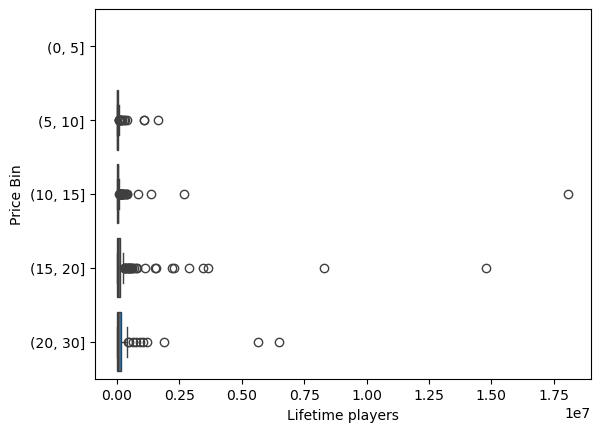

In [74]:
sns.boxplot(data=data, x='Lifetime players', y='bin')
plt.ylabel("Price Bin")
#plt.xscale("log")

In [76]:
data.groupby('bin')['Lifetime players'].describe()

/var/folders/vh/qvl8gx_d2m370qv72srt5r1m0000gp/T/ipykernel_83832/3375425347.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('bin')['Lifetime players'].describe()


,count,mean,std,min,25%,50%,75%,max
bin,,,,,,,,
"(0, 5]",0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(5, 10]",111.0,66744.189189,2.147329e+05,431.0,6432.0,15418.0,31339.50,1654852.0
"(10, 15]",143.0,206216.594406,1.527842e+06,889.0,6219.0,18972.0,39431.00,18072293.0
"(15, 20]",212.0,282492.042453,1.244044e+06,702.0,12921.0,37110.5,113052.25,14802690.0
"(20, 30]",74.0,324081.729730,1.015815e+06,1309.0,11523.5,38946.5,173913.00,6477263.0


<Axes: xlabel='Avg. days played', ylabel='bin'>

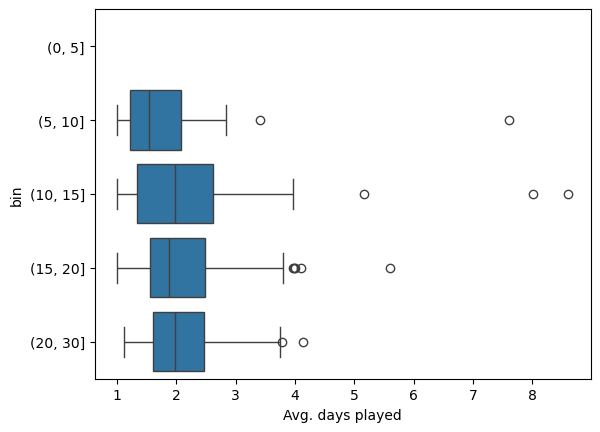

In [33]:
sns.boxplot(data=data, x='Avg. days played', y='bin')


<Axes: xlabel='Stickiness', ylabel='bin'>

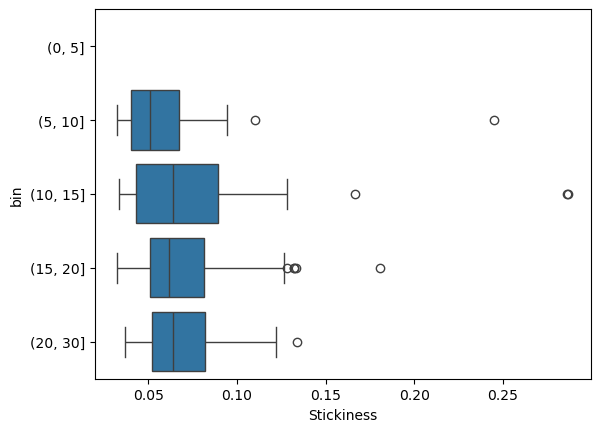

In [68]:
sns.boxplot(data=data, x='Stickiness', y='bin')
